In [99]:
#test again, use this version

"""
Simulated Annealing – Bus Route Redesign and Stop Assignment Optimisation
=========================================================================
Singapore bus services 4, 19, 20, 23, 29, 37, 69, 81, 127,
                        291, 292, 293, 296, 460  (Tampines area)
Depot: Tampines Bus Interchange (75009)

Formulation reference (Section 2, HST_Project_Draft_2):

Decision variables:
    x[z][i][j]  – route traversal (implicit in ordered route lists)
    y[z][i]     – stop assignment (stop i in service z's list)
    u[i]        – stop coverage  (1 if i in ≥1 service list)
    o[z][i]     – position of stop i in service z's route (subtour elim)

Objectives:
    f1 = Σ_z Σ_{i,j} d_{ij} x_{zij}   (total travel distance)
    f2 = Σ_i d_i (1 − u_i)             (total demand loss)

Constraints:
    C1  Each service departs  depot exactly once
    C2  Each service returns  depot exactly once
    C3  Flow conservation at non-depot stops
    C4  Linking: y_{zi}=1 → in/out degree 1 at i for z
    C5  Overlapping allowed: Σ_z y_{zi} ∈ {0,1,2,...}
    C6  u_i ≤ Σ_z y_{zi};  u_i ≥ y_{zi} ∀z
    C7  Σ_i y_{zi} ≤ K  ∀z                      (max stops per service)
    C8  Σ_{ij} d_{ij} x_{zij} ≤ D_z  ∀z          (max route distance, optional)
    C9  No subtours  (guaranteed by list representation)

"""

import math
import random
import time
import copy
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline


# ─────────────────────────────────────────────────────────────────────────────
# 0.  FILE PATHS 
# ─────────────────────────────────────────────────────────────────────────────

MATCHED_STOPS_FILE   = "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\matched_bus_stops_all_services.csv"
PASSENGER_VOL_FILE   = "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\filtered data\\total passenger vol.csv"

SERVICE_DIST_FILES = {
    4: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 4.csv",
    19: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 19.csv",
    20: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 20.csv",
    23: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 23.csv",
    29: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 29.csv",
    37: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 37.csv",
    69: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 69.csv",
    81: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 81.csv",
    127: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 127.csv",
    291: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 291.csv",
    292: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 292.csv",
    293: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 293.csv",
    296: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 296.csv",
    460: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 460.csv",
}

PERIOD_LABELS = {
    "morning_0700_0900":  "morning_peak",
    "afternoon_1300_1500":"off_peak",
    "evening_1800_2000":  "evening_peak",
}

DEMAND_DECAY_ALPHA = 0.12   # distance-decay rate for per-stop demand distribution


# ─────────────────────────────────────────────────────────────────────────────
# 1.  UTILITY
# ─────────────────────────────────────────────────────────────────────────────

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi    = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


# ─────────────────────────────────────────────────────────────────────────────
# 2.  DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────

def _interpolate_coords(stop, svc_stops, svc_cums, coord_map):
    """
    Linearly interpolate lon/lat for a stop missing from coord_map,
    using its cumulative-distance position between nearest known neighbours.
    """
    idx = svc_stops.index(stop)
    prev = next(k for k in range(idx-1, -1, -1) if svc_stops[k] in coord_map)
    nxt  = next(k for k in range(idx+1, len(svc_stops)) if svc_stops[k] in coord_map)
    sp, sn = svc_stops[prev], svc_stops[nxt]
    cp, cn = svc_cums[prev],  svc_cums[nxt]
    t = (svc_cums[idx] - cp) / (cn - cp) if cn != cp else 0.5
    lon = coord_map[sp][0] + t*(coord_map[sn][0] - coord_map[sp][0])
    lat = coord_map[sp][1] + t*(coord_map[sn][1] - coord_map[sp][1])
    return lon, lat


def load_data():
    """
    Load and pre-process all datasets.
    Returns a single data-dict consumed by all downstream functions.
    """
    DEPOT = 75009

    # ── 2a. Stop coordinates ─────────────────────────────────────────────────
    stops_df  = pd.read_csv(MATCHED_STOPS_FILE)
    coord_map = {
        int(r.BUS_STOP_NUM): (r.longitude, r.latitude)
        for r in stops_df.itertuples(index=False)
    }

    # ── 2b. Route sequences for every service ────────────────────────────────
    service_routes = {}
    for svc, fpath in SERVICE_DIST_FILES.items():
        df = pd.read_csv(fpath)
        service_routes[svc] = {
            "stops":    df["Bus Stop Code"].astype(int).tolist(),
            "cum_dist": df["Cumulative Distance"].tolist(),
        }

    # ── 2c. Fill missing coordinates by linear interpolation ─────────────────
    depot_lon, depot_lat = coord_map[DEPOT]
    for svc, info in service_routes.items():
        svc_stops = info["stops"]
        svc_cums  = info["cum_dist"]
        for stop in svc_stops:
            if stop != DEPOT and stop not in coord_map:
                coord_map[stop] = _interpolate_coords(
                    stop, svc_stops, svc_cums, coord_map)

    # ── 2d. Candidate stop universe (all non-depot stops across all services) ─
    all_stops = sorted(
        {s for info in service_routes.values()
           for s in info["stops"] if s != DEPOT}
    )

    # ── 2e. Pairwise haversine distance matrix ───────────────────────────────
    nodes    = [DEPOT] + all_stops
    distance = {}
    for i in nodes:
        li, ai = coord_map[i]
        for j in nodes:
            lj, aj = coord_map[j]
            distance[i, j] = 0.0 if i == j else haversine_km(li, ai, lj, aj)

    # ── 2f. Per-stop demand (distance-decay from interchange-level totals) ────
    vol_df = pd.read_csv(PASSENGER_VOL_FILE)
    vol_df.columns = ["month","day_type","period","tap_in","tap_out","total"]

    avg_demand_total = {}
    for raw, label in PERIOD_LABELS.items():
        avg_demand_total[label] = float(vol_df[vol_df["period"]==raw]["total"].mean())

    weights = {
        s: math.exp(-DEMAND_DECAY_ALPHA *
                    haversine_km(depot_lon, depot_lat, coord_map[s][0], coord_map[s][1]))
        for s in all_stops
    }
    w_sum = sum(weights.values())
    demand = {
        label: {s: (weights[s]/w_sum)*total for s in all_stops}
        for label, total in avg_demand_total.items()
    }

    # ── 2g. Original sequences as warm-start ─────────────────────────────────
    original_routes = {
        svc: [s for s in info["stops"] if s != DEPOT]
        for svc, info in service_routes.items()
    }

    return {
        "depot":            DEPOT,
        "stops":            all_stops,
        "services":         list(SERVICE_DIST_FILES.keys()),
        "coord_map":        coord_map,
        "distance":         distance,
        "demand":           demand,
        "avg_demand_total": avg_demand_total,
        "original_routes":  original_routes,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 3.  SOLUTION  (encodes all four decision variables)
# ─────────────────────────────────────────────────────────────────────────────

class Solution:
    """
    routes: {service_z: [ordered stop list]}

    Formulation variable mapping
    ────────────────────────────
    x_{z,i,j} = 1  if j immediately follows i in routes[z]
    y_{z,i}   = 1  if stop i is in routes[z]          → self.y()
    u_i       = 1  if stop i in ≥1 routes[z]           → self.u()
    o_{z,i}   = 1-indexed position in routes[z]         → self.o()

    Constraints C1–C4, C9 are structurally satisfied by the representation.
    """
    def __init__(self, routes):
        self.routes = {z: list(r) for z, r in routes.items()}

    def copy(self):
        return Solution({z: list(r) for z, r in self.routes.items()})

    def y(self, z, stop):
        return 1 if stop in self.routes[z] else 0

    def u(self, stop):
        return 1 if any(stop in r for r in self.routes.values()) else 0

    def o(self, z, stop):
        r = self.routes[z]
        return r.index(stop)+1 if stop in r else 0

    def served_stops(self):
        return {s for r in self.routes.values() for s in r}

    def unserved_stops(self, all_stops):
        served = self.served_stops()
        return [s for s in all_stops if s not in served]


# ─────────────────────────────────────────────────────────────────────────────
# 4.  INITIAL SOLUTION
# ─────────────────────────────────────────────────────────────────────────────

def build_initial_solution(data, max_stops_k):
    """
    Warm-start from original sequences; first-come-first-served to avoid
    duplicate assignments across services. Truncated to max_stops_k.
    """
    assigned = set()
    routes   = {}
    for z, orig in data["original_routes"].items():
        route = []
        for s in orig:
            if len(route) >= max_stops_k:
                break
            if s not in assigned:
                route.append(s)
                assigned.add(s)
        routes[z] = route
    return Solution(routes)


# ─────────────────────────────────────────────────────────────────────────────
# 5.  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(sol, data, period, w_dist, w_loss, max_stops_k, max_dist_dz):
    """
    Returns (f1, f2, composite, feasible, violations).

    f1 = Σ_z Σ_{i,j} d_{ij} x_{zij}          Objective 1 – total distance
    f2 = Σ_i d_i(1 − u_i)                     Objective 2 – demand loss
    composite = w_dist*f1 + w_loss*f2          Weighted-sum scalarisation
    C7: len(route) ≤ K,  C8: route_dist ≤ D_z  (if enabled)
    """
    depot    = data["depot"]
    dist     = data["distance"]
    demand   = data["demand"][period]
    stops    = data["stops"]

    total_distance = 0.0
    violations     = {}

    for z, route in sol.routes.items():
        if not route:
            continue
        rd = dist[depot, route[0]]
        for k in range(len(route)-1):
            rd += dist[route[k], route[k+1]]
        rd += dist[route[-1], depot]
        total_distance += rd

        if len(route) > max_stops_k:
            violations[f"C7_svc{z}"] = len(route) - max_stops_k
        if max_dist_dz is not None and rd > max_dist_dz:
            violations[f"C8_svc{z}"] = rd - max_dist_dz

    served_demand = sum(demand[s] for s in stops if sol.u(s) == 1)
    total_demand  = sum(demand.values())
    f2 = total_demand - served_demand

    feasible  = len(violations) == 0
    composite = w_dist*total_distance + w_loss*f2
    return total_distance, f2, composite, feasible, violations


# ─────────────────────────────────────────────────────────────────────────────
# 6.  NEIGHBOURHOOD OPERATORS
# ─────────────────────────────────────────────────────────────────────────────

def _cheap_insert(route, stop, depot, dist):
    best_pos, best_delta = 0, float("inf")
    for p in range(len(route)+1):
        prev  = depot if p == 0        else route[p-1]
        nxt   = depot if p == len(route) else route[p]
        delta = dist[prev, stop] + dist[stop, nxt] - dist[prev, nxt]
        if delta < best_delta:
            best_delta, best_pos = delta, p
    return best_pos, best_delta


def op_relocate(sol, data, max_stops_k):
    """
    (a) INSERT_UNSERVED – move an unserved stop into a route (cheapest position)
    (b) MOVE_BETWEEN    – move a stop from one route to another
    (c) REMOVE_TO_POOL  – drop a stop from a route

    Modifies y_{z,i} and potentially u_i.
    """
    depot    = data["depot"]
    dist     = data["distance"]
    services = data["services"]
    stops    = data["stops"]
    new_sol  = sol.copy()

    # served_list = [(z, idx, s)
    #                for z, r in new_sol.routes.items()
    #                for idx, s in enumerate(r)]
    # unserved = new_sol.unserved_stops(stops)
    # if not served_list:
    #     return new_sol
    served_list = [
    (z, idx, s)
    for z, r in new_sol.routes.items()
    for idx, s in enumerate(r)]

    unserved = new_sol.unserved_stops(stops)

    if not served_list and unserved:
        s = random.choice(unserved)
        z = random.choice(services)
        new_sol.routes[z].append(s)
        return new_sol

    weights_op = [0.45 if unserved else 0.0, 0.40, 0.15]
    move = random.choices(["insert_unserved","move_between","remove_to_pool"],
                          weights=weights_op)[0]

    if move == "insert_unserved" and unserved:
        s = random.choice(unserved)
        z = random.choice(services)
        if len(new_sol.routes[z]) >= max_stops_k:
            return new_sol
        pos, _ = _cheap_insert(new_sol.routes[z], s, depot, dist)
        new_sol.routes[z].insert(pos, s)

    elif move == "move_between" and len(services) > 1:
        z_from, idx, s = random.choice(served_list)
        z_to = random.choice([z for z in services if z != z_from])
        if len(new_sol.routes[z_to]) >= max_stops_k:
            return new_sol
        new_sol.routes[z_from].pop(idx)
        pos, _ = _cheap_insert(new_sol.routes[z_to], s, depot, dist)
        new_sol.routes[z_to].insert(pos, s)

    else:
        z, idx, _ = random.choice(served_list)
        new_sol.routes[z].pop(idx)

    return new_sol


def op_swap(sol, data):
    """
    Swap two stops (within same route → reorder x; between routes → swap y).
    """
    new_sol = sol.copy()
    served  = [(z, idx, s)
               for z, r in new_sol.routes.items()
               for idx, s in enumerate(r)]
    if len(served) < 2:
        return new_sol
    (z1, i1, s1), (z2, i2, s2) = random.sample(served, 2)
    if z1 == z2 and s1 == s2:
        return new_sol
    new_sol.routes[z1][i1] = s2
    new_sol.routes[z2][i2] = s1
    return new_sol


def op_two_opt(sol, data):
    """
    Reverse a contiguous segment within one route (improves x ordering).
    """
    new_sol  = sol.copy()
    eligible = [z for z, r in new_sol.routes.items() if len(r) >= 3]
    if not eligible:
        return new_sol
    z = random.choice(eligible)
    r = new_sol.routes[z]
    i, j = sorted(random.sample(range(len(r)), 2))
    new_sol.routes[z][i:j+1] = reversed(r[i:j+1])
    return new_sol


def op_or_opt(sol, data, max_stops_k):
    """
    Move a segment of 1–3 stops from one route to another at cheapest position
    (modifies both x and y variables).
    """
    depot    = data["depot"]
    dist     = data["distance"]
    services = data["services"]
    new_sol  = sol.copy()
    seg_len  = random.choice([1, 2, 3])

    eligible = [z for z, r in new_sol.routes.items() if len(r) >= seg_len]
    if not eligible or len(services) < 2:
        return new_sol

    z_from = random.choice(eligible)
    r_from = new_sol.routes[z_from]
    i      = random.randrange(len(r_from) - seg_len + 1)
    segment= r_from[i:i+seg_len]

    z_to = random.choice([z for z in services if z != z_from])
    if len(new_sol.routes[z_to]) + seg_len > max_stops_k:
        return new_sol

    new_sol.routes[z_from] = r_from[:i] + r_from[i+seg_len:]

    r_to         = new_sol.routes[z_to]
    seg_int_dist = sum(dist[segment[k], segment[k+1]] for k in range(len(segment)-1))
    best_pos, best_cost = 0, float("inf")
    for p in range(len(r_to)+1):
        prev = depot if p == 0         else r_to[p-1]
        nxt  = depot if p == len(r_to) else r_to[p]
        cost = dist[prev, segment[0]] + seg_int_dist + dist[segment[-1], nxt] - dist[prev, nxt]
        if cost < best_cost:
            best_cost, best_pos = cost, p
    new_sol.routes[z_to] = r_to[:best_pos] + segment + r_to[best_pos:]
    return new_sol


_OPERATORS = [op_relocate, op_swap, op_two_opt, op_or_opt]
_OP_WEIGHTS = [0.40, 0.25, 0.25, 0.10]


# ─────────────────────────────────────────────────────────────────────────────
# 7.  SIMULATED ANNEALING
# ─────────────────────────────────────────────────────────────────────────────

def simulated_annealing(
    data,
    period,
    w_dist          = 1.0,
    w_loss          = 1.0,
    max_stops_k     = 20,
    max_dist_dz     = 40,
    T_init          = 8000.0,
    T_final         = 1.0,
    cooling_rate    = 0.9975,
    max_iter        = 100_000,
    verbose         = True,
):
    """
    Returns (best_solution, f1, f2, cpu_time_log, obj_log)
    where cpu_time_log[i] and obj_log[i] are the wall-clock time (s) and best
    composite objective value recorded at iteration i, used for plotting.
    """
    current = build_initial_solution(data, max_stops_k)
    f1, f2, cost, _, _ = evaluate(current, data, period,
                                   w_dist, w_loss, max_stops_k, max_dist_dz)
    best            = current.copy()
    best_f1, best_f2, best_cost = f1, f2, cost

    T            = T_init
    cpu_time_log = []
    obj_log      = []          # composite objective (w_dist*f1 + w_loss*f2)
    iter_log     = []  
    t0           = time.perf_counter()

    for iteration in range(1, max_iter+1):
        if T < T_final:
            break

        op = random.choices(_OPERATORS, weights=_OP_WEIGHTS)[0]
        if op is op_relocate:
            neighbour = op_relocate(current, data, max_stops_k)
        elif op is op_swap:
            neighbour = op_swap(current, data)
        elif op is op_two_opt:
            neighbour = op_two_opt(current, data)
        else:
            neighbour = op_or_opt(current, data, max_stops_k)

        nf1, nf2, n_cost, n_feasible, violations = evaluate(
            neighbour, data, period, w_dist, w_loss, max_stops_k, max_dist_dz)

        # Soft penalty for infeasible solutions
        if not n_feasible:
            n_cost += sum(violations.values()) * T_init * 0.1

        delta = n_cost - cost
        if delta < 0 or random.random() < math.exp(-delta / T):
            current = neighbour
            cost, f1, f2 = n_cost, nf1, nf2

        # Track best FEASIBLE solution
        _, _, _, cur_feasible, _ = evaluate(current, data, period,
                                             w_dist, w_loss, max_stops_k, max_dist_dz)
        if cur_feasible and cost < best_cost:
            best      = current.copy()
            best_cost = cost
            best_f1, best_f2 = f1, f2

        # Log every 200 iterations for a smooth curve without too many points
        if iteration % 200 == 0:
            cpu_time_log.append(time.perf_counter() - t0)
            obj_log.append(best_cost)
            iter_log.append(iteration)

        T *= cooling_rate

        if verbose and iteration % 10_000 == 0:
            n_sv = len(best.served_stops())
            print(f"  Iter {iteration:6d} | T={T:7.1f} | "
                  f"dist={best_f1:7.2f} km | demand_loss={best_f2:9.1f} | "
                  f"stops={n_sv}/{len(data['stops'])}")

    return best, best_f1, best_f2, cpu_time_log, obj_log, iter_log

# Plot the balanced solution for each period
for period in ["morning_peak", "off_peak", "evening_peak"]:
    balanced = next(r for r in all_results[period]
                    if r["w_dist"] == 1.0 and r["w_loss"] == 0.010)
    m = plot_routes_on_map(
        sol      = balanced["solution"],
        data     = data,
        period   = period,
        out_path = r"C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html"
    )
    display(m)   # renders the map inline in Jupyter

# ─────────────────────────────────────────────────────────────────────────────
# 8.  PARETO EXPERIMENT  (weight sweep)
# ─────────────────────────────────────────────────────────────────────────────

def run_pareto_experiment(data, period, max_stops_k=20, max_dist_dz=40):
    """
    Sweep (w_dist, w_loss) pairs to approximate the Pareto front.
    Returns list of result dicts, each containing the solution, objectives,
    and CPU-time / objective logs for plotting.
    """
    weight_pairs = [
        (1.0, 0.000),
        (1.0, 0.002),
        (1.0, 0.005),
        (1.0, 0.010),
        (0.5, 0.010),
        (0.1, 0.010),
    ]
    total_demand = sum(data["demand"][period].values())
    results      = []

    print(f"\n{'─'*80}")
    print(f"  SA Pareto Sweep | Period: {period.upper()} | "
          f"K={max_stops_k} | "
          f"D_z={'∞' if max_dist_dz is None else f'{max_dist_dz} km'} | "
          f"Services: {len(data['services'])} | Stops: {len(data['stops'])}")
    print(f"{'─'*80}")

    for w_dist, w_loss in weight_pairs:
        print(f"\n  → w_dist={w_dist}, w_loss={w_loss}")
        sol, f1, f2, t_log, o_log, i_log = simulated_annealing(
            data, period,
            w_dist=w_dist, w_loss=w_loss,
            max_stops_k=max_stops_k, max_dist_dz=max_dist_dz,
            verbose=False,
        )
        n_served     = len(sol.served_stops())
        coverage_pct = 100.0 * (1.0 - f2/total_demand)
        print(f"     f1={f1:7.2f} km | f2={f2:9.1f} | "
              f"stops={n_served}/{len(data['stops'])} | "
              f"coverage={coverage_pct:.1f}%")

        results.append({
            "period":         period,
            "w_dist":         w_dist,
            "w_loss":         w_loss,
            "f1_km":          f1,
            "f2_loss":        f2,
            "stops_served":   n_served,
            "coverage_pct":   coverage_pct,
            "solution":       sol,
            "cpu_time_log":   t_log,
            "obj_log":        o_log,
            "iter_log":       i_log,
        })

    return results


# ─────────────────────────────────────────────────────────────────────────────
# 9.  PLOTTING
# ─────────────────────────────────────────────────────────────────────────────

def plot_objective_vs_time(all_results, out_path="sa_objective_vs_time.png"):
    """
    One figure with one subplot per time period.
    Each subplot overlays one curve per (w_dist, w_loss) weight combination,
    showing how the best composite objective value falls over CPU time.
    """
    periods   = list(all_results.keys())
    n_periods = len(periods)

    fig, axes = plt.subplots(1, n_periods, figsize=(6.5*n_periods, 5),
                              sharey=False)
    if n_periods == 1:
        axes = [axes]

    period_titles = {
        "morning_peak": "Morning Peak (07:00–09:00)",
        "off_peak":     "Off-Peak (13:00–15:00)",
        "evening_peak": "Evening Peak (18:00–20:00)",
    }

    # Colour palette – one colour per weight combination
    colours = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]

    for ax, period in zip(axes, periods):
        results = all_results[period]
        for i, r in enumerate(results):
            label = f"w_d={r['w_dist']}, w_l={r['w_loss']}"
            ax.plot(r["cpu_time_log"], r["obj_log"],
                    color=colours[i % len(colours)],
                    linewidth=1.8, label=label)

        ax.set_title(period_titles.get(period, period), fontsize=12, fontweight="bold")
        ax.set_xlabel("CPU Time (s)", fontsize=10)
        ax.set_ylabel("Best Composite Objective\n(w₁·f₁ + w₂·f₂)", fontsize=10)
        ax.legend(fontsize=7.5, loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(
            lambda x, _: f"{x:,.0f}"))

    fig.suptitle(
        "Simulated Annealing – Objective Value vs CPU Time\n"
        f"({len(next(iter(all_results.values()))[0]['solution'].routes)} services, "
        f"{len(data['stops'])} candidate stops)",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"\n  Plot saved → {out_path}")
    return fig


def plot_pareto_front(all_results, out_path="sa_pareto_front.png"):
    """
    Scatter plot of (f1, f2) trade-off points across all periods.
    Each period is a different colour; each weight pair is a point.
    """
    period_colours = {
        "morning_peak": "#1f77b4",
        "off_peak":     "#ff7f0e",
        "evening_peak": "#2ca02c",
    }
    period_labels = {
        "morning_peak": "Morning Peak",
        "off_peak":     "Off-Peak",
        "evening_peak": "Evening Peak",
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for period, results in all_results.items():
        f1s = [r["f1_km"]  for r in results]
        f2s = [r["f2_loss"] for r in results]
        ax.scatter(f1s, f2s, label=period_labels.get(period, period),
                   color=period_colours.get(period, "grey"),
                   s=80, zorder=3, edgecolors="white", linewidths=0.5)
        # Connect points in weight-sweep order
        ax.plot(f1s, f2s, color=period_colours.get(period, "grey"),
                linewidth=1, linestyle="--", alpha=0.5)

    ax.set_xlabel("f₁ – Total Travel Distance (km)", fontsize=11)
    ax.set_ylabel("f₂ – Total Demand Loss", fontsize=11)
    ax.set_title("Approximate Pareto Front: Distance vs Demand Loss",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Plot saved → {out_path}")
    return fig

def plot_objective_vs_iterations(all_results, out_path="sa_objective_vs_iterations.png"):
    """
    One subplot per time period. Each line shows how the best composite
    objective value improves as SA iterations increase, for each weight pair.
    """
    periods   = list(all_results.keys())
    n_periods = len(periods)

    fig, axes = plt.subplots(1, n_periods, figsize=(6.5 * n_periods, 5), sharey=False)
    if n_periods == 1:
        axes = [axes]

    period_titles = {
        "morning_peak": "Morning Peak (07:00–09:00)",
        "off_peak":     "Off-Peak (13:00–15:00)",
        "evening_peak": "Evening Peak (18:00–20:00)",
    }
    colours = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    for ax, period in zip(axes, periods):
        for i, r in enumerate(all_results[period]):
            label = f"w_d={r['w_dist']}, w_l={r['w_loss']}"
            ax.plot(r["iter_log"], r["obj_log"],
                    color=colours[i % len(colours)],
                    linewidth=1.8, label=label)

        ax.set_title(period_titles.get(period, period), fontsize=12, fontweight="bold")
        ax.set_xlabel("Iterations", fontsize=10)
        ax.set_ylabel("Best Composite Objective\n(w₁·f₁ + w₂·f₂)", fontsize=10)
        ax.legend(fontsize=7.5, loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    fig.suptitle(
        "Simulated Annealing – Objective Value vs Iterations",
        fontsize=13, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved → {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
# 10. Print
# ─────────────────────────────────────────────────────────────────────────────

def print_solution_detail(sol, data, period):
    depot  = data["depot"]
    dist   = data["distance"]
    demand = data["demand"][period]
    stops  = data["stops"]

    print(f"\n{'═'*72}")
    print(f"  SOLUTION DETAIL   Period: {period.upper()}")
    print(f"{'═'*72}")

    total_dist = 0.0
    for z, route in sol.routes.items():
        if not route:
            print(f"  Service {z:>3d}: [empty]")
            continue
        rd = dist[depot, route[0]]
        for k in range(len(route)-1):
            rd += dist[route[k], route[k+1]]
        rd += dist[route[-1], depot]
        total_dist += rd
        svc_demand = sum(demand[s] for s in route)
        print(f"  Service {z:>3d} | {len(route):2d} stops | {rd:6.2f} km | "
              f"demand={svc_demand:,.0f}")
        route_str = f"{depot} → " + " → ".join(str(s) for s in route) + f" → {depot}"
        for chunk in [route_str[i:i+70] for i in range(0, len(route_str), 70)]:
            print(f"    {chunk}")

    served   = sol.served_stops()
    unserved = sol.unserved_stops(stops)
    total_d  = sum(demand.values())
    served_d = sum(demand[s] for s in served)

    print(f"\n  f1  Total distance : {total_dist:.2f} km")
    print(f"  f2  Demand loss    : {total_d - served_d:,.1f}")
    print(f"      Demand served  : {served_d:,.1f} / {total_d:,.1f}  "
          f"({100*served_d/total_d:.1f}%)")
    print(f"      Stops served   : {len(served)} / {len(stops)}")
    if unserved:
        print(f"      Unserved stops : {unserved}")
    # Decision variable summary
    print(f"\n  Decision variable summary (formulation §2.2):")
    n_arcs = sum(len(r)+1 for r in sol.routes.values() if r) * 2
    n_y    = sum(len(r) for r in sol.routes.values())
    max_K  = max((len(r) for r in sol.routes.values()), default=0)
    print(f"    x_{{z,i,j}} : {n_arcs} route-traversal arcs")
    print(f"    y_{{z,i}}   : {n_y} stop-service assignments")
    print(f"    u_i        : {len(served)} stops with u_i=1")
    print(f"    o_{{z,i}}   : positions 1..{max_K} per service")


def print_summary_table(all_results, data):
    print(f"\n{'═'*108}")
    print("  PARETO FRONT SUMMARY — ALL PERIODS")
    print(f"{'═'*108}")
    hdr = (f"  {'Period':<16} {'w_dist':<8} {'w_loss':<9} "
           f"{'f1 (km)':<12} {'f2 demand loss':<17} {'Coverage%':<12} {'Stops'}")
    print(hdr)
    print(f"  {'─'*104}")
    for period, res_list in all_results.items():
        for r in res_list:
            print(f"  {r['period']:<16} {r['w_dist']:<8} {r['w_loss']:<9} "
                  f"{r['f1_km']:<12.2f} {r['f2_loss']:<17.1f} "
                  f"{r['coverage_pct']:<12.1f} "
                  f"{r['stops_served']}/{len(data['stops'])}")
        print(f"  {'─'*104}")


# ─────────────────────────────────────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Problem parameters ────────────────────────────────────────────────────
    MAX_K        = 20      # K  : max stops per service              (C7)
    MAX_DIST_DZ  = 40    # D_z: max route km        (C8)
    MAX_ITER     = 100_000  # SA iteration budget per run
    COOLING_RATE = 0.9975  # geometric cooling α

    # ── Load data ─────────────────────────────────────────────────────────────
    #print("Loading data...")
    data = load_data()
    print(f"  Depot           : {data['depot']} (Tampines Bus Interchange)")
    print(f"  Candidate stops : {len(data['stops'])}")
    print(f"  Services        : {data['services']}  ({len(data['services'])} total)")
    print(f"  Max stops K     : {MAX_K}  "
          f"(capacity = {MAX_K * len(data['services'])} stops)")
    print(f"  Max route dist  : {'disabled' if MAX_DIST_DZ is None else f'{MAX_DIST_DZ} km'}")
    print(f"\n  Avg interchange demand (Mar–May 2026):")
    for p, v in data["avg_demand_total"].items():
        print(f"    {p:<15} : {v:>10,.0f}")

    # ── Run SA for all three time periods ─────────────────────────────────────
    all_results = {}
    for period in ["morning_peak", "off_peak", "evening_peak"]:
        results = run_pareto_experiment(
            data, period,
            max_stops_k=MAX_K,
            max_dist_dz=MAX_DIST_DZ,
        )
        all_results[period] = results
        # Print detail for the balanced weight pair (w_dist=1.0, w_loss=0.010)
        balanced = next(r for r in results
                        if r["w_dist"] == 1.0 and r["w_loss"] == 0.010)
        print_solution_detail(balanced["solution"], data, period)

    # ── Summary table ──
    print_summary_table(all_results, data)

    # ── Plots ───
    plot_objective_vs_time(all_results,
                           out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_objective_vs_time.png")
    plot_pareto_front(all_results,
                      out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_pareto_front.png")
    plot_objective_vs_iterations(all_results,
    out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_objective_vs_iterations.png")

Map saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html


Map saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html


Map saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html


  Depot           : 75009 (Tampines Bus Interchange)
  Candidate stops : 355
  Services        : [4, 19, 20, 23, 29, 37, 69, 81, 127, 291, 292, 293, 296, 460]  (14 total)
  Max stops K     : 20  (capacity = 280 stops)
  Max route dist  : 40 km

  Avg interchange demand (Mar–May 2026):
    morning_peak    :    285,896
    off_peak        :    190,514
    evening_peak    :    313,893

────────────────────────────────────────────────────────────────────────────────
  SA Pareto Sweep | Period: MORNING_PEAK | K=20 | D_z=40 km | Services: 14 | Stops: 355
────────────────────────────────────────────────────────────────────────────────

  → w_dist=1.0, w_loss=0.0
     f1= 146.42 km | f2=  79193.6 | stops=243/355 | coverage=72.3%

  → w_dist=1.0, w_loss=0.002
     f1= 146.42 km | f2=  79193.6 | stops=243/355 | coverage=72.3%

  → w_dist=1.0, w_loss=0.005
     f1= 146.42 km | f2=  79193.6 | stops=243/355 | coverage=72.3%

  → w_dist=1.0, w_loss=0.01
     f1= 151.05 km | f2=  77156.2 | stops=245/

In [97]:
#folium map
!pip install folium
import folium
from folium import plugins

def plot_routes_on_map(sol, data, period, out_path=None):
    """
    Plots the optimised bus routes and stops on an interactive map.

    Each service gets a unique colour. Clicking a stop marker shows
    the stop code, which service serves it, and its demand value.
    The depot is marked with a special interchange icon.

    Parameters
    ----------
    sol      : Solution object from simulated_annealing()
    data     : data dict from load_data()
    period   : 'morning_peak' | 'off_peak' | 'evening_peak'
    out_path : optional filepath to save as .html (e.g. "routes.html")
    """
    depot     = data["depot"]
    coord_map = data["coord_map"]
    demand    = data["demand"][period]

    # Folium uses (lat, lon) — our coord_map stores (lon, lat), so swap
    def latlon(stop):
        lon, lat = coord_map[stop]
        return (lat, lon)

    # ── Colour palette — one per service ──────────────────────────────────────
    COLOURS = [
        "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
        "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
        "#dcbeff", "#9A6324", "#800000", "#aaffc3",
    ]
    services   = [z for z, r in sol.routes.items() if r]  # only non-empty
    colour_map = {z: COLOURS[i % len(COLOURS)] for i, z in enumerate(services)}

    # ── Initialise map centred on depot ───────────────────────────────────────
    depot_lat, depot_lon_swap = latlon(depot)
    m = folium.Map(
        location=[depot_lat, depot_lon_swap],
        zoom_start=13,
        tiles="CartoDB positron",   # clean light basemap
    )

    # ── Legend (HTML overlay) ─────────────────────────────────────────────────
    legend_rows = "".join(
        f'<tr><td><span style="background:{colour_map[z]};'
        f'display:inline-block;width:18px;height:12px;border-radius:2px"></span></td>'
        f'<td style="padding-left:6px">Service {z}</td></tr>'
        for z in services
    )
    legend_html = f"""
    <div style="position:fixed;bottom:40px;left:40px;z-index:1000;
                background:white;padding:10px 14px;border-radius:6px;
                border:1px solid #ccc;font-size:12px;font-family:sans-serif;
                box-shadow:2px 2px 6px rgba(0,0,0,.15)">
      <b>Bus Services</b><br>
      <table style="margin-top:6px;border-collapse:collapse">
        {legend_rows}
        <tr><td><span style="background:#333;display:inline-block;
                width:18px;height:12px;border-radius:50%"></span></td>
            <td style="padding-left:6px">Depot (75009)</td></tr>
      </table>
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    # ── Draw each service's route ─────────────────────────────────────────────
    for z, route in sol.routes.items():
        if not route:
            continue
        colour = colour_map[z]

        # Full path including depot → stops → depot
        full_path = [depot] + route + [depot]
        coords    = [latlon(s) for s in full_path]

        # Route polyline
        folium.PolyLine(
            locations=coords,
            color=colour,
            weight=3.5,
            opacity=0.85,
            tooltip=f"Service {z}",
        ).add_to(m)

        # # Arrowheads to show direction of travel
        # plugins.AntPath(
        #     locations=coords,
        #     color=colour,
        #     weight=3,
        #     opacity=0.5,
        #     delay=800,
        #     dash_array=[15, 30],
        #     pulse_color="#ffffff",
        #     tooltip=f"Service {z} direction",
        # ).add_to(m)

        # ── Stop markers ──────────────────────────────────────────────────────
        for pos, stop in enumerate(route, start=1):
            stop_demand = demand.get(stop, 0)
            popup_html  = (
                f"<b>Stop {stop}</b><br>"
                f"Service: {z}<br>"
                f"Position: {pos} of {len(route)}<br>"
                f"Demand ({period}): {stop_demand:,.0f}"
            )
            folium.CircleMarker(
                location=latlon(stop),
                radius=6,
                color=colour,
                fill=True,
                fill_color=colour,
                fill_opacity=0.85,
                weight=1.5,
                popup=folium.Popup(popup_html, max_width=200),
                tooltip=f"Stop {stop} | Svc {z}",
            ).add_to(m)

    # ── Unserved stops (grey, smaller) ────────────────────────────────────────
    served   = sol.served_stops()
    unserved = [s for s in data["stops"] if s not in served]
    for stop in unserved:
        folium.CircleMarker(
            location=latlon(stop),
            radius=4,
            color="#aaaaaa",
            fill=True,
            fill_color="#cccccc",
            fill_opacity=0.5,
            weight=1,
            popup=folium.Popup(
                f"<b>Stop {stop}</b><br>⚠ UNSERVED<br>"
                f"Demand lost: {demand.get(stop,0):,.0f}",
                max_width=180,
            ),
            tooltip=f"Stop {stop} — unserved",
        ).add_to(m)

    # ── Depot marker ──────────────────────────────────────────────────────────
    folium.Marker(
        location=latlon(depot),
        popup=folium.Popup(
            f"<b>Tampines Bus Interchange</b><br>Stop: {depot}<br>"
            f"<i>Depot — all routes start and end here</i>",
            max_width=220,
        ),
        tooltip="Depot — Tampines Interchange (75009)",
        icon=folium.Icon(color="black", icon="bus", prefix="fa"),
    ).add_to(m)

    # ── Stats box (top right) ─────────────────────────────────────────────────
    total_d = sum(demand.values())
    served_d = sum(demand[s] for s in served)
    dist_total = sum(
        data["distance"][depot, r[0]] +
        sum(data["distance"][r[k], r[k+1]] for k in range(len(r)-1)) +
        data["distance"][r[-1], depot]
        for r in sol.routes.values() if r
    )
    stats_html = f"""
    <div style="position:fixed;top:20px;right:20px;z-index:1000;
                background:white;padding:10px 14px;border-radius:6px;
                border:1px solid #ccc;font-size:12px;font-family:sans-serif;
                box-shadow:2px 2px 6px rgba(0,0,0,.15);min-width:200px">
      <b>Solution Summary</b><br>
      <table style="margin-top:6px;border-collapse:collapse;width:100%">
        <tr><td>Period</td><td style="text-align:right"><b>{period.replace("_"," ").title()}</b></td></tr>
        <tr><td>Total distance</td><td style="text-align:right"><b>{dist_total:.1f} km</b></td></tr>
        <tr><td>Stops served</td><td style="text-align:right"><b>{len(served)} / {len(data["stops"])}</b></td></tr>
        <tr><td>Demand coverage</td><td style="text-align:right"><b>{100*served_d/total_d:.1f}%</b></td></tr>
        <tr><td>Demand loss</td><td style="text-align:right"><b>{total_d-served_d:,.0f}</b></td></tr>
      </table>
    </div>"""
    m.get_root().html.add_child(folium.Element(stats_html))

    if out_path:
        m.save(out_path)
        print(f"Map saved → {out_path}")

    return m   # displays inline in Jupyter when returned as the last expression

In [73]:
#ver 5
# ============================================================
# Operator Performance Comparison for Cell 3
# ============================================================

import random
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def simulated_annealing_fixed_operator(
    data,
    period,
    operator_name,
    w_dist=1.0,
    w_loss=0.010,
    max_stops_k=20,
    max_dist_dz=50,
    T_init=8000.0,
    T_final=1.0,
    cooling_rate=0.9975,
    max_iter=150_000,
    log_every=200,
    seed=1,
):
    import random
    import time
    import math

    random.seed(seed)

    operator_map = {
        "op_relocate": op_relocate,
        "op_swap": op_swap,
        "op_two_opt": op_two_opt,
        "op_or_opt": op_or_opt,
    }

    if operator_name not in operator_map:
        raise ValueError(f"Unknown operator: {operator_name}")

    operator = operator_map[operator_name]

    current = build_initial_solution(data, max_stops_k)

    f1, f2, cost, feasible, violations = evaluate(
        current,
        data,
        period,
        w_dist,
        w_loss,
        max_stops_k,
        max_dist_dz
    )

    if not feasible:
        cost += sum(violations.values()) * T_init * 0.1

    best = current.copy()
    best_f1 = f1
    best_f2 = f2
    best_cost = cost

    T = T_init
    t0 = time.perf_counter()

    iter_log = []
    time_log = []
    current_obj_log = []
    best_obj_log = []
    best_f1_log = []
    best_f2_log = []

    accepted_count = 0
    improvement_count = 0
    changed_count = 0

    for iteration in range(1, max_iter + 1):

        if T < T_final:
            break

        old_routes_repr = repr(current.routes)

        if operator_name in ["op_relocate", "op_or_opt"]:
            neighbour = operator(current, data, max_stops_k)
        else:
            neighbour = operator(current, data)

        if repr(neighbour.routes) != old_routes_repr:
            changed_count += 1

        nf1, nf2, n_cost, n_feasible, n_violations = evaluate(
            neighbour,
            data,
            period,
            w_dist,
            w_loss,
            max_stops_k,
            max_dist_dz
        )

        if not n_feasible:
            n_cost += sum(n_violations.values()) * T_init * 0.1

        delta = n_cost - cost

        if delta < 0:
            accept = True
        else:
            accept = random.random() < math.exp(-delta / max(T, 1e-12))

        if accept:
            current = neighbour
            cost = n_cost
            f1 = nf1
            f2 = nf2
            accepted_count += 1

        # Update best feasible solution only
        cur_f1, cur_f2, cur_cost, cur_feasible, cur_violations = evaluate(
            current,
            data,
            period,
            w_dist,
            w_loss,
            max_stops_k,
            max_dist_dz
        )

        if cur_feasible and cur_cost < best_cost:
            best = current.copy()
            best_cost = cur_cost
            best_f1 = cur_f1
            best_f2 = cur_f2
            improvement_count += 1

        if iteration % log_every == 0:
            iter_log.append(iteration)
            time_log.append(time.perf_counter() - t0)

            # Important: log both current and best
            current_obj_log.append(cost)
            best_obj_log.append(best_cost)
            best_f1_log.append(best_f1)
            best_f2_log.append(best_f2)

        T *= cooling_rate

    runtime = time.perf_counter() - t0

    if len(iter_log) == 0:
        iter_log.append(iteration)
        time_log.append(runtime)
        current_obj_log.append(cost)
        best_obj_log.append(best_cost)
        best_f1_log.append(best_f1)
        best_f2_log.append(best_f2)

    return {
        "operator": operator_name,
        "period": period,
        "seed": seed,
        "best_solution": best,
        "best_objective": best_cost,
        "best_f1_distance": best_f1,
        "best_f2_demand_loss": best_f2,
        "iterations_completed": iteration,
        "runtime_seconds": runtime,
        "acceptance_rate": accepted_count / max(1, iteration),
        "improvement_count": improvement_count,
        "changed_rate": changed_count / max(1, iteration),
        "iter_log": iter_log,
        "time_log": time_log,
        "current_obj_log": current_obj_log,
        "best_obj_log": best_obj_log,

        # Keep this for compatibility with your old plotting code
        "obj_log": best_obj_log,
        "f1_log": best_f1_log,
        "f2_log": best_f2_log,
    }
    
# ============================================================
# 2. Run operator comparison
# ============================================================

def run_operator_comparison(
    data,
    period="morning_peak",
    w_dist=1.0,
    w_loss=0.010,
    max_stops_k=20,
    max_dist_dz=50,
    max_iter=150_000,
    cooling_rate=0.9975,
    seed=1,
):
    operators = [
        "op_relocate",
        "op_swap",
        "op_two_opt",
        "op_or_opt",
    ]

    results = []

    print("\n" + "=" * 90)
    print(f"Operator comparison for period: {period}")
    print("=" * 90)

    for op_name in operators:
        print(f"\nRunning {op_name}...", flush=True)

        result = simulated_annealing_fixed_operator(
            data=data,
            period=period,
            operator_name=op_name,
            w_dist=w_dist,
            w_loss=w_loss,
            max_stops_k=max_stops_k,
            max_dist_dz=max_dist_dz,
            T_init=8000.0,
            T_final=1.0,
            cooling_rate=cooling_rate,
            max_iter=max_iter,
            log_every=200,
            seed=seed,
        )

        results.append(result)

        print(
            f"{op_name:<15} | "
            f"Objective={result['best_objective']:.2f} | "
            f"Distance={result['best_f1_distance']:.2f} km | "
            f"Demand loss={result['best_f2_demand_loss']:.1f} | "
            f"Acceptance={100 * result['acceptance_rate']:.2f}% | "
            f"Runtime={result['runtime_seconds']:.2f}s"
        )

    return results

operator_results = run_operator_comparison(
    data=data,
    period="morning_peak",
    w_dist=1.0,
    w_loss=0.010,
    max_stops_k=20,
    max_dist_dz=35,
    max_iter=50_000,
    cooling_rate=0.9975,
    seed=1,
)

# ============================================================
# 3. Plot objective value against iterations
# ============================================================

def plot_operator_objective_vs_iterations(
    operator_results,
    out_path=None
):
    plt.figure(figsize=(8, 5))

    for result in operator_results:
        plt.plot(
            result["iter_log"],
            result["obj_log"],
            linewidth=1.8,
            label=result["operator"]
        )

    plt.xlabel("Iterations")
    plt.ylabel("Best composite objective")
    plt.title("Operator comparison: objective value vs iterations")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {out_path}")

    plt.show()


plot_operator_objective_vs_iterations(
    operator_results,
    out_path="operator_objective_vs_iterations.png"
)

# ============================================================
# 4. Plot objective value against CPU time
# ============================================================

def plot_operator_objective_vs_time(
    operator_results,
    out_path=None
):
    plt.figure(figsize=(8, 5))

    for result in operator_results:
        plt.plot(
            result["time_log"],
            result["obj_log"],
            linewidth=1.8,
            label=result["operator"]
        )

    plt.xlabel("CPU time, seconds")
    plt.ylabel("Best composite objective")
    plt.title("Operator comparison: objective value vs CPU time")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {out_path}")

    plt.show()


plot_operator_objective_vs_time(
    operator_results,
    out_path="operator_objective_vs_time.png"
)

# ============================================================
# 5. Bar chart of final objective values
# ============================================================

def plot_operator_final_objective(
    operator_results,
    out_path=None
):
    summary = pd.DataFrame([
        {
            "operator": r["operator"],
            "best_objective": r["best_objective"],
            "distance_km": r["best_f1_distance"],
            "demand_loss": r["best_f2_demand_loss"],
            "acceptance_rate": r["acceptance_rate"],
            "runtime_seconds": r["runtime_seconds"],
            "improvement_count": r["improvement_count"],
        }
        for r in operator_results
    ])

    summary = summary.sort_values("best_objective", ascending=True)

    plt.figure(figsize=(8, 5))

    plt.bar(
        summary["operator"],
        summary["best_objective"]
    )

    plt.xlabel("Neighbourhood operator")
    plt.ylabel("Final best composite objective")
    plt.title("Final objective value by operator")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {out_path}")

    plt.show()

    return summary


operator_summary = plot_operator_final_objective(
    operator_results,
    out_path="operator_final_objective.png"
)

operator_summary

# ============================================================
# 6. Scatter plot: distance vs demand loss
# ============================================================

def plot_operator_distance_vs_demand_loss(
    operator_results,
    out_path=None
):
    plt.figure(figsize=(7, 5))

    for result in operator_results:
        plt.scatter(
            result["best_f1_distance"],
            result["best_f2_demand_loss"],
            s=80,
            label=result["operator"]
        )

        plt.annotate(
            result["operator"],
            (
                result["best_f1_distance"],
                result["best_f2_demand_loss"]
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.xlabel("Total travel distance, km")
    plt.ylabel("Demand loss")
    plt.title("Operator comparison: distance vs demand loss")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {out_path}")

    plt.show()


plot_operator_distance_vs_demand_loss(
    operator_results,
    out_path="operator_distance_vs_demand_loss.png"
)

def plot_operator_current_and_best(operator_results, out_path=None):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    plt.figure(figsize=(9, 5))

    for r in operator_results:
        plt.plot(
            r["iter_log"],
            r["current_obj_log"],
            linestyle=":",
            alpha=0.6,
            label=f"{r['operator']} current"
        )

        plt.plot(
            r["iter_log"],
            r["best_obj_log"],
            linewidth=2,
            label=f"{r['operator']} best"
        )

    plt.xlabel("Iterations")
    plt.ylabel("Composite objective")
    plt.title("Operator comparison: current vs best objective")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(fontsize=8)

    plt.gca().xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {out_path}")
    plt.show()


plot_operator_current_and_best(
    operator_results,
    out_path="operator_current_and_best.png")


Operator comparison for period: morning_peak

Running op_relocate...
op_relocate     | Objective=938.36 | Distance=146.42 km | Demand loss=79193.6 | Acceptance=86.72% | Runtime=13.05s

Running op_swap...
op_swap         | Objective=938.36 | Distance=146.42 km | Demand loss=79193.6 | Acceptance=22.16% | Runtime=14.01s

Running op_two_opt...
op_two_opt      | Objective=938.36 | Distance=146.42 km | Demand loss=79193.6 | Acceptance=79.73% | Runtime=12.65s

Running op_or_opt...
op_or_opt       | Objective=938.36 | Distance=146.42 km | Demand loss=79193.6 | Acceptance=79.51% | Runtime=13.16s
Plot saved to: operator_objective_vs_iterations.png


C:\Users\User\AppData\Local\Temp\ipykernel_32608\269775039.py:297: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to: operator_objective_vs_time.png


C:\Users\User\AppData\Local\Temp\ipykernel_32608\269775039.py:339: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to: operator_final_objective.png


C:\Users\User\AppData\Local\Temp\ipykernel_32608\269775039.py:392: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to: operator_distance_vs_demand_loss.png


C:\Users\User\AppData\Local\Temp\ipykernel_32608\269775039.py:448: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to: operator_current_and_best.png


C:\Users\User\AppData\Local\Temp\ipykernel_32608\269775039.py:496: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Map saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html


  Depot           : 75009 (Tampines Bus Interchange)
  Candidate stops : 355
  Services        : [4, 19, 20, 23, 29, 37, 69, 81, 127, 291, 292, 293, 296, 460]  (14 total)
  Max stops K     : 20  (capacity = 280 stops)
  Max route dist  : 40 km

  Avg interchange demand (Mar–May 2026):
    morning_peak    :    285,896
    off_peak        :    190,514
    evening_peak    :    313,893

────────────────────────────────────────────────────────────────────────────────
  SA Pareto Sweep | Period: MORNING_PEAK | K=20 | D_z=40 km | Services: 14 | Stops: 355
────────────────────────────────────────────────────────────────────────────────

  → w_dist=1.0, w_loss=0.0
SA completed | accepted=2164/3592 (60.24%) | feasible neighbours=9.94% | improvements=0
     f1= 146.42 km | f2=  79193.6 | stops=243/355 | coverage=72.3%

  → w_dist=1.0, w_loss=0.002
SA completed | accepted=2183/3592 (60.77%) | feasible neighbours=25.39% | improvements=0
     f1= 146.42 km | f2=  79193.6 | stops=243/355 | coverage=7

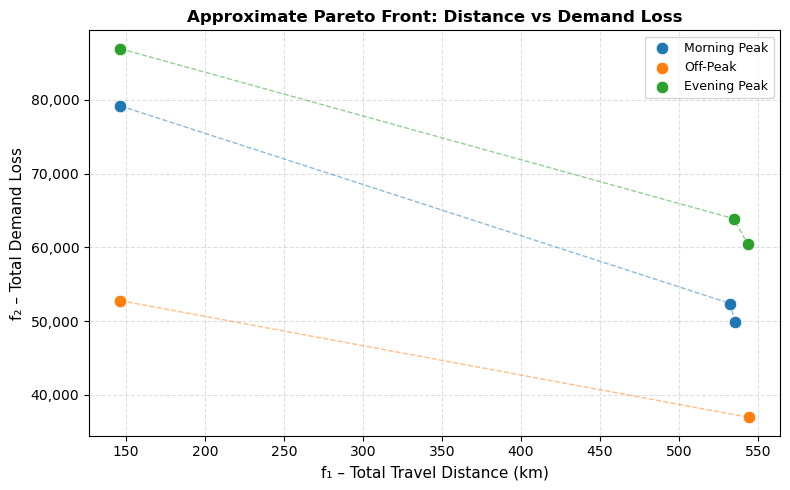

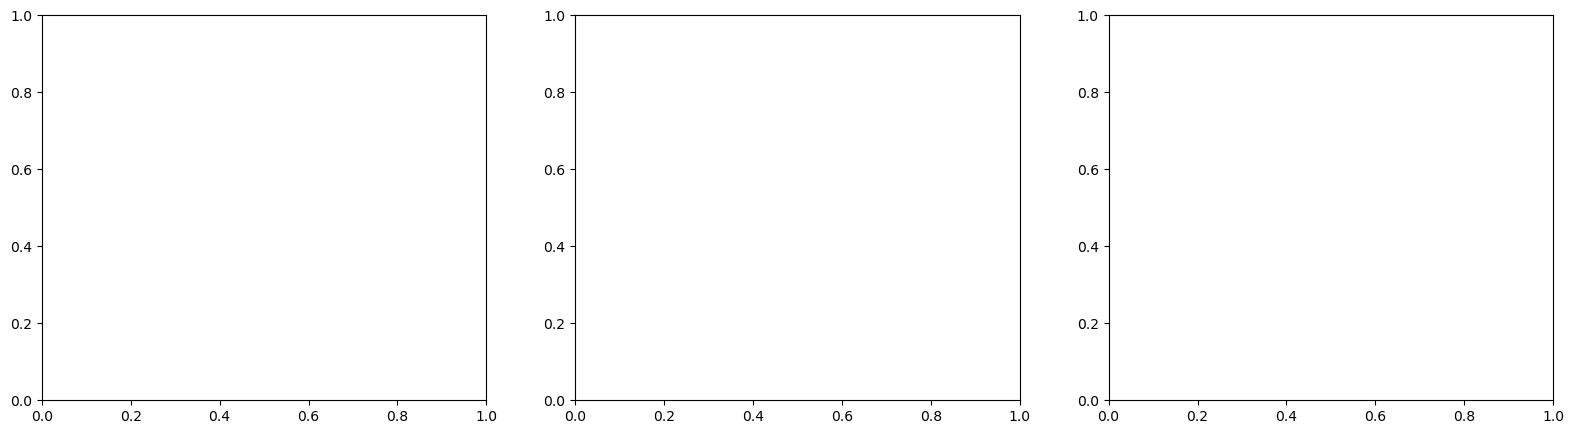

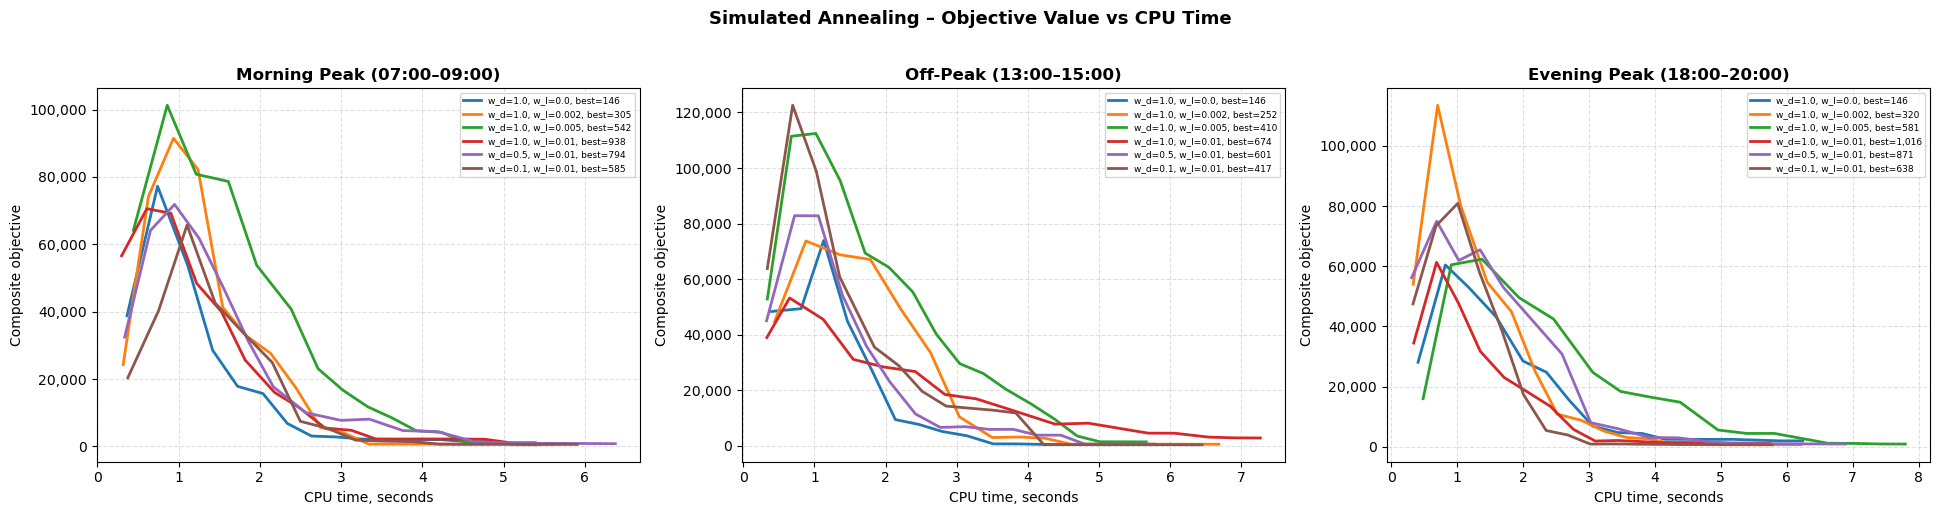

Plot saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\sa_objective_vs_time.png
  Plot saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\sa_pareto_front.png


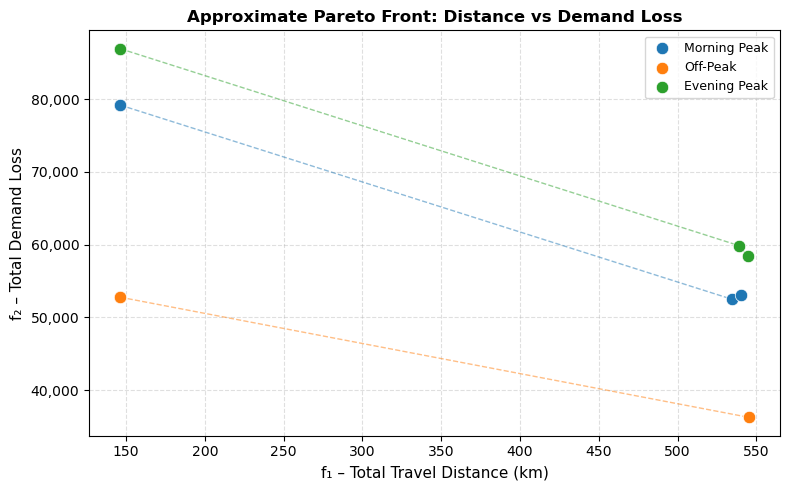

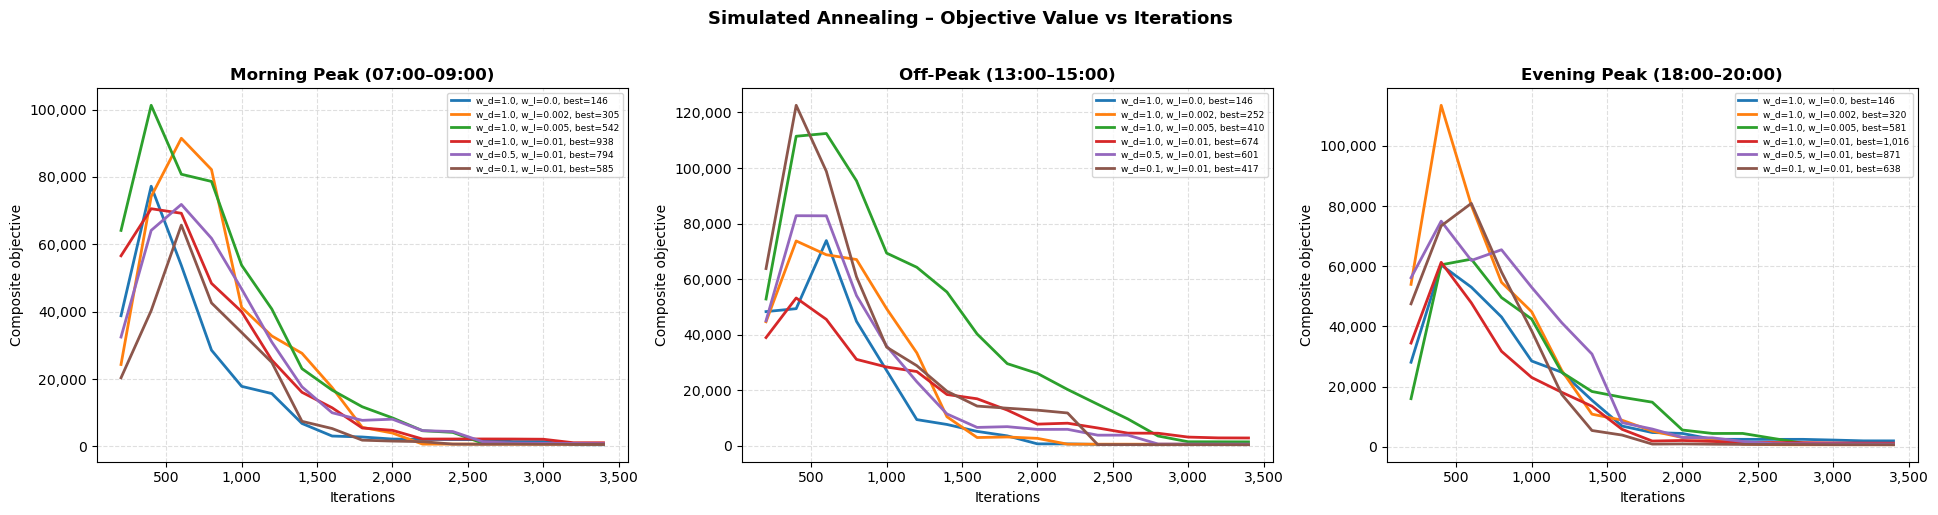

Plot saved → C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\sa_objective_vs_iterations.png


In [132]:
#USE THIS ONE test again, see if the graph plots properly

"""
Simulated Annealing – Bus Route Redesign and Stop Assignment Optimisation
=========================================================================
Singapore bus services 4, 19, 20, 23, 29, 37, 69, 81, 127,
                        291, 292, 293, 296, 460  (Tampines area)
Depot: Tampines Bus Interchange (75009)

Formulation reference (Section 2, HST_Project_Draft_2):

Decision variables:
    x[z][i][j]  – route traversal (implicit in ordered route lists)
    y[z][i]     – stop assignment (stop i in service z's list)
    u[i]        – stop coverage  (1 if i in ≥1 service list)
    o[z][i]     – position of stop i in service z's route (subtour elim)

Objectives:
    f1 = Σ_z Σ_{i,j} d_{ij} x_{zij}   (total travel distance)
    f2 = Σ_i d_i (1 − u_i)             (total demand loss)

Constraints:
    C1  Each service departs  depot exactly once
    C2  Each service returns  depot exactly once
    C3  Flow conservation at non-depot stops
    C4  Linking: y_{zi}=1 → in/out degree 1 at i for z
    C5  Overlapping allowed: Σ_z y_{zi} ∈ {0,1,2,...}
    C6  u_i ≤ Σ_z y_{zi};  u_i ≥ y_{zi} ∀z
    C7  Σ_i y_{zi} ≤ K  ∀z                      (max stops per service)
    C8  Σ_{ij} d_{ij} x_{zij} ≤ D_z  ∀z          (max route distance, optional)
    C9  No subtours  (guaranteed by list representation)

"""

import math
import random
import time
import copy
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline


# ─────────────────────────────────────────────────────────────────────────────
# 0.  FILE PATHS 
# ─────────────────────────────────────────────────────────────────────────────

MATCHED_STOPS_FILE   = "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\matched_bus_stops_all_services.csv"
PASSENGER_VOL_FILE   = "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\filtered data\\total passenger vol.csv"

SERVICE_DIST_FILES = {
    4: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 4.csv",
    19: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 19.csv",
    20: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 20.csv",
    23: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 23.csv",
    29: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 29.csv",
    37: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 37.csv",
    69: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 69.csv",
    81: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 81.csv",
    127: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 127.csv",
    291: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 291.csv",
    292: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 292.csv",
    293: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 293.csv",
    296: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 296.csv",
    460: "C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\distance data\\dist from origin 460.csv",
}

PERIOD_LABELS = {
    "morning_0700_0900":  "morning_peak",
    "afternoon_1300_1500":"off_peak",
    "evening_1800_2000":  "evening_peak",
}

DEMAND_DECAY_ALPHA = 0.12   # distance-decay rate for per-stop demand distribution


# ─────────────────────────────────────────────────────────────────────────────
# 1.  UTILITY
# ─────────────────────────────────────────────────────────────────────────────

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi    = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


# ─────────────────────────────────────────────────────────────────────────────
# 2.  DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────

def _interpolate_coords(stop, svc_stops, svc_cums, coord_map):
    """
    Linearly interpolate lon/lat for a stop missing from coord_map,
    using its cumulative-distance position between nearest known neighbours.
    """
    idx = svc_stops.index(stop)
    prev = next(k for k in range(idx-1, -1, -1) if svc_stops[k] in coord_map)
    nxt  = next(k for k in range(idx+1, len(svc_stops)) if svc_stops[k] in coord_map)
    sp, sn = svc_stops[prev], svc_stops[nxt]
    cp, cn = svc_cums[prev],  svc_cums[nxt]
    t = (svc_cums[idx] - cp) / (cn - cp) if cn != cp else 0.5
    lon = coord_map[sp][0] + t*(coord_map[sn][0] - coord_map[sp][0])
    lat = coord_map[sp][1] + t*(coord_map[sn][1] - coord_map[sp][1])
    return lon, lat


def load_data():
    """
    Load and pre-process all datasets.
    Returns a single data-dict consumed by all downstream functions.
    """
    DEPOT = 75009

    # ── 2a. Stop coordinates ─────────────────────────────────────────────────
    stops_df  = pd.read_csv(MATCHED_STOPS_FILE)
    coord_map = {
        int(r.BUS_STOP_NUM): (r.longitude, r.latitude)
        for r in stops_df.itertuples(index=False)
    }

    # ── 2b. Route sequences for every service ────────────────────────────────
    service_routes = {}
    for svc, fpath in SERVICE_DIST_FILES.items():
        df = pd.read_csv(fpath)
        service_routes[svc] = {
            "stops":    df["Bus Stop Code"].astype(int).tolist(),
            "cum_dist": df["Cumulative Distance"].tolist(),
        }

    # ── 2c. Fill missing coordinates by linear interpolation ─────────────────
    depot_lon, depot_lat = coord_map[DEPOT]
    for svc, info in service_routes.items():
        svc_stops = info["stops"]
        svc_cums  = info["cum_dist"]
        for stop in svc_stops:
            if stop != DEPOT and stop not in coord_map:
                coord_map[stop] = _interpolate_coords(
                    stop, svc_stops, svc_cums, coord_map)

    # ── 2d. Candidate stop universe (all non-depot stops across all services) ─
    all_stops = sorted(
        {s for info in service_routes.values()
           for s in info["stops"] if s != DEPOT}
    )

    # ── 2e. Pairwise haversine distance matrix ───────────────────────────────
    nodes    = [DEPOT] + all_stops
    distance = {}
    for i in nodes:
        li, ai = coord_map[i]
        for j in nodes:
            lj, aj = coord_map[j]
            distance[i, j] = 0.0 if i == j else haversine_km(li, ai, lj, aj)

    # ── 2f. Per-stop demand (distance-decay from interchange-level totals) ────
    vol_df = pd.read_csv(PASSENGER_VOL_FILE)
    vol_df.columns = ["month","day_type","period","tap_in","tap_out","total"]

    avg_demand_total = {}
    for raw, label in PERIOD_LABELS.items():
        avg_demand_total[label] = float(vol_df[vol_df["period"]==raw]["total"].mean())

    weights = {
        s: math.exp(-DEMAND_DECAY_ALPHA *
                    haversine_km(depot_lon, depot_lat, coord_map[s][0], coord_map[s][1]))
        for s in all_stops
    }
    w_sum = sum(weights.values())
    demand = {
        label: {s: (weights[s]/w_sum)*total for s in all_stops}
        for label, total in avg_demand_total.items()
    }

    # ── 2g. Original sequences as warm-start ─────────────────────────────────
    original_routes = {
        svc: [s for s in info["stops"] if s != DEPOT]
        for svc, info in service_routes.items()
    }

    return {
        "depot":            DEPOT,
        "stops":            all_stops,
        "services":         list(SERVICE_DIST_FILES.keys()),
        "coord_map":        coord_map,
        "distance":         distance,
        "demand":           demand,
        "avg_demand_total": avg_demand_total,
        "original_routes":  original_routes,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 3.  SOLUTION  (encodes all four decision variables)
# ─────────────────────────────────────────────────────────────────────────────

class Solution:
    """
    routes: {service_z: [ordered stop list]}

    Formulation variable mapping
    ────────────────────────────
    x_{z,i,j} = 1  if j immediately follows i in routes[z]
    y_{z,i}   = 1  if stop i is in routes[z]          → self.y()
    u_i       = 1  if stop i in ≥1 routes[z]           → self.u()
    o_{z,i}   = 1-indexed position in routes[z]         → self.o()

    Constraints C1–C4, C9 are structurally satisfied by the representation.
    """
    def __init__(self, routes):
        self.routes = {z: list(r) for z, r in routes.items()}

    def copy(self):
        return Solution({z: list(r) for z, r in self.routes.items()})

    def y(self, z, stop):
        return 1 if stop in self.routes[z] else 0

    def u(self, stop):
        return 1 if any(stop in r for r in self.routes.values()) else 0

    def o(self, z, stop):
        r = self.routes[z]
        return r.index(stop)+1 if stop in r else 0

    def served_stops(self):
        return {s for r in self.routes.values() for s in r}

    def unserved_stops(self, all_stops):
        served = self.served_stops()
        return [s for s in all_stops if s not in served]


# ─────────────────────────────────────────────────────────────────────────────
# 4.  INITIAL SOLUTION
# ─────────────────────────────────────────────────────────────────────────────

def build_initial_solution(data, max_stops_k):
    """
    Warm-start from original sequences; first-come-first-served to avoid
    duplicate assignments across services. Truncated to max_stops_k.
    """
    assigned = set()
    routes   = {}
    for z, orig in data["original_routes"].items():
        route = []
        for s in orig:
            if len(route) >= max_stops_k:
                break
            if s not in assigned:
                route.append(s)
                assigned.add(s)
        routes[z] = route
    return Solution(routes)


# ─────────────────────────────────────────────────────────────────────────────
# 5.  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(sol, data, period, w_dist, w_loss, max_stops_k, max_dist_dz):
    """
    Returns (f1, f2, composite, feasible, violations).

    f1 = Σ_z Σ_{i,j} d_{ij} x_{zij}          Objective 1 – total distance
    f2 = Σ_i d_i(1 − u_i)                     Objective 2 – demand loss
    composite = w_dist*f1 + w_loss*f2          Weighted-sum scalarisation
    C7: len(route) ≤ K,  C8: route_dist ≤ D_z  (if enabled)
    """
    depot    = data["depot"]
    dist     = data["distance"]
    demand   = data["demand"][period]
    stops    = data["stops"]

    total_distance = 0.0
    violations     = {}

    for z, route in sol.routes.items():
        if not route:
            continue
        rd = dist[depot, route[0]]
        for k in range(len(route)-1):
            rd += dist[route[k], route[k+1]]
        rd += dist[route[-1], depot]
        total_distance += rd

        if len(route) > max_stops_k:
            violations[f"C7_svc{z}"] = len(route) - max_stops_k
        if max_dist_dz is not None and rd > max_dist_dz:
            violations[f"C8_svc{z}"] = rd - max_dist_dz

    served_demand = sum(demand[s] for s in stops if sol.u(s) == 1)
    total_demand  = sum(demand.values())
    f2 = total_demand - served_demand

    feasible  = len(violations) == 0
    composite = w_dist*total_distance + w_loss*f2
    return total_distance, f2, composite, feasible, violations


# ─────────────────────────────────────────────────────────────────────────────
# 6.  NEIGHBOURHOOD OPERATORS
# ─────────────────────────────────────────────────────────────────────────────

def _cheap_insert(route, stop, depot, dist):
    best_pos, best_delta = 0, float("inf")
    for p in range(len(route)+1):
        prev  = depot if p == 0        else route[p-1]
        nxt   = depot if p == len(route) else route[p]
        delta = dist[prev, stop] + dist[stop, nxt] - dist[prev, nxt]
        if delta < best_delta:
            best_delta, best_pos = delta, p
    return best_pos, best_delta


def op_relocate(sol, data, max_stops_k):
    """
    (a) INSERT_UNSERVED – move an unserved stop into a route (cheapest position)
    (b) MOVE_BETWEEN    – move a stop from one route to another
    (c) REMOVE_TO_POOL  – drop a stop from a route

    Modifies y_{z,i} and potentially u_i.
    """
    depot    = data["depot"]
    dist     = data["distance"]
    services = data["services"]
    stops    = data["stops"]
    new_sol  = sol.copy()

    # served_list = [(z, idx, s)
    #                for z, r in new_sol.routes.items()
    #                for idx, s in enumerate(r)]
    # unserved = new_sol.unserved_stops(stops)
    # if not served_list:
    #     return new_sol
    served_list = [
    (z, idx, s)
    for z, r in new_sol.routes.items()
    for idx, s in enumerate(r)]

    unserved = new_sol.unserved_stops(stops)

    if not served_list and unserved:
        s = random.choice(unserved)
        z = random.choice(services)
        new_sol.routes[z].append(s)
        return new_sol

    weights_op = [0.45 if unserved else 0.0, 0.40, 0.15]
    move = random.choices(["insert_unserved","move_between","remove_to_pool"],
                          weights=weights_op)[0]

    if move == "insert_unserved" and unserved:
        s = random.choice(unserved)
        z = random.choice(services)
        if len(new_sol.routes[z]) >= max_stops_k:
            return new_sol
        pos, _ = _cheap_insert(new_sol.routes[z], s, depot, dist)
        new_sol.routes[z].insert(pos, s)

    elif move == "move_between" and len(services) > 1:
        z_from, idx, s = random.choice(served_list)
        z_to = random.choice([z for z in services if z != z_from])
        if len(new_sol.routes[z_to]) >= max_stops_k:
            return new_sol
        new_sol.routes[z_from].pop(idx)
        pos, _ = _cheap_insert(new_sol.routes[z_to], s, depot, dist)
        new_sol.routes[z_to].insert(pos, s)

    else:
        z, idx, _ = random.choice(served_list)
        new_sol.routes[z].pop(idx)

    return new_sol


def op_swap(sol, data):
    """
    Swap two stops (within same route → reorder x; between routes → swap y).
    """
    new_sol = sol.copy()
    served  = [(z, idx, s)
               for z, r in new_sol.routes.items()
               for idx, s in enumerate(r)]
    if len(served) < 2:
        return new_sol
    (z1, i1, s1), (z2, i2, s2) = random.sample(served, 2)
    if z1 == z2 and s1 == s2:
        return new_sol
    new_sol.routes[z1][i1] = s2
    new_sol.routes[z2][i2] = s1
    return new_sol


def op_two_opt(sol, data):
    """
    Reverse a contiguous segment within one route (improves x ordering).
    """
    new_sol  = sol.copy()
    eligible = [z for z, r in new_sol.routes.items() if len(r) >= 3]
    if not eligible:
        return new_sol
    z = random.choice(eligible)
    r = new_sol.routes[z]
    i, j = sorted(random.sample(range(len(r)), 2))
    new_sol.routes[z][i:j+1] = reversed(r[i:j+1])
    return new_sol


def op_or_opt(sol, data, max_stops_k):
    """
    Move a segment of 1–3 stops from one route to another at cheapest position
    (modifies both x and y variables).
    """
    depot    = data["depot"]
    dist     = data["distance"]
    services = data["services"]
    new_sol  = sol.copy()
    seg_len  = random.choice([1, 2, 3])

    eligible = [z for z, r in new_sol.routes.items() if len(r) >= seg_len]
    if not eligible or len(services) < 2:
        return new_sol

    z_from = random.choice(eligible)
    r_from = new_sol.routes[z_from]
    i      = random.randrange(len(r_from) - seg_len + 1)
    segment= r_from[i:i+seg_len]

    z_to = random.choice([z for z in services if z != z_from])
    if len(new_sol.routes[z_to]) + seg_len > max_stops_k:
        return new_sol

    new_sol.routes[z_from] = r_from[:i] + r_from[i+seg_len:]

    r_to         = new_sol.routes[z_to]
    seg_int_dist = sum(dist[segment[k], segment[k+1]] for k in range(len(segment)-1))
    best_pos, best_cost = 0, float("inf")
    for p in range(len(r_to)+1):
        prev = depot if p == 0         else r_to[p-1]
        nxt  = depot if p == len(r_to) else r_to[p]
        cost = dist[prev, segment[0]] + seg_int_dist + dist[segment[-1], nxt] - dist[prev, nxt]
        if cost < best_cost:
            best_cost, best_pos = cost, p
    new_sol.routes[z_to] = r_to[:best_pos] + segment + r_to[best_pos:]
    return new_sol


_OPERATORS = [op_relocate, op_swap, op_two_opt, op_or_opt]
_OP_WEIGHTS = [0.40, 0.25, 0.25, 0.10]


# ─────────────────────────────────────────────────────────────────────────────
# 7.  SIMULATED ANNEALING
# ─────────────────────────────────────────────────────────────────────────────

def simulated_annealing(
    data,
    period,
    w_dist          = 1.0,
    w_loss          = 1.0,
    max_stops_k     = 20,
    max_dist_dz     = 40,
    T_init          = 8000.0,
    T_final         = 1.0,
    cooling_rate    = 0.9975,
    max_iter        = 150_000,
    verbose         = True,
):
    

    current = build_initial_solution(data, max_stops_k)

    f1, f2, raw_cost, feasible, violations = evaluate(
        current,
        data,
        period,
        w_dist,
        w_loss,
        max_stops_k,
        max_dist_dz
    )

    penalty_factor = T_init * 0.1

    if feasible:
        current_cost = raw_cost
    else:
        current_cost = raw_cost + sum(violations.values()) * penalty_factor

    # Track best feasible solution only
    if feasible:
        best = current.copy()
        best_f1 = f1
        best_f2 = f2
        best_cost = raw_cost
    else:
        best = None
        best_f1 = None
        best_f2 = None
        best_cost = float("inf")

    T = T_init
    t0 = time.perf_counter()

    cpu_time_log = []
    iter_log = []

    # best feasible objective over time
    obj_log = []

    # current accepted solution objective over time
    current_obj_log = []

    # distance and demand-loss logs for diagnostics
    f1_log = []
    f2_log = []

    accepted_count = 0
    improved_count = 0
    feasible_count = 0

    for iteration in range(1, max_iter + 1):

        if T < T_final:
            break

        op = random.choices(_OPERATORS, weights=_OP_WEIGHTS)[0]

        if op is op_relocate:
            neighbour = op_relocate(current, data, max_stops_k)
        elif op is op_swap:
            neighbour = op_swap(current, data)
        elif op is op_two_opt:
            neighbour = op_two_opt(current, data)
        else:
            neighbour = op_or_opt(current, data, max_stops_k)

        nf1, nf2, n_raw_cost, n_feasible, n_violations = evaluate(
            neighbour,
            data,
            period,
            w_dist,
            w_loss,
            max_stops_k,
            max_dist_dz
        )

        if n_feasible:
            n_cost = n_raw_cost
            feasible_count += 1
        else:
            n_cost = n_raw_cost + sum(n_violations.values()) * penalty_factor

        delta = n_cost - current_cost

        if delta < 0:
            accept = True
        else:
            accept_prob = math.exp(-delta / max(T, 1e-12))
            accept = random.random() < accept_prob

        if accept:
            current = neighbour
            current_cost = n_cost
            f1 = nf1
            f2 = nf2
            raw_cost = n_raw_cost
            feasible = n_feasible
            accepted_count += 1

        # Update best feasible solution only
        if feasible and raw_cost < best_cost:
            best = current.copy()
            best_cost = raw_cost
            best_f1 = f1
            best_f2 = f2
            improved_count += 1

        # Log every 200 iterations
        if iteration % 200 == 0:
            cpu_time_log.append(time.perf_counter() - t0)
            iter_log.append(iteration)

            # Current solution objective, including penalty if infeasible
            current_obj_log.append(current_cost)

            # Best feasible objective
            # If no feasible solution has been found yet, record current penalised cost
            if best_cost < float("inf"):
                obj_log.append(best_cost)
                f1_log.append(best_f1)
                f2_log.append(best_f2)
            else:
                obj_log.append(current_cost)
                f1_log.append(f1)
                f2_log.append(f2)

        T *= cooling_rate

        if verbose and iteration % 10_000 == 0:
            if best is not None:
                n_sv = len(best.served_stops())
                print(
                    f"  Iter {iteration:6d} | T={T:7.1f} | "
                    f"best={best_cost:,.2f} | dist={best_f1:7.2f} km | "
                    f"demand_loss={best_f2:9.1f} | stops={n_sv}/{len(data['stops'])}"
                )
            else:
                print(
                    f"  Iter {iteration:6d} | T={T:7.1f} | "
                    f"No feasible best yet | current penalised cost={current_cost:,.2f}"
                )

    # If no feasible solution was ever found, return the final current solution
    if best is None:
        print("Warning: No feasible solution found. Returning final current solution.")
        best = current.copy()
        best_f1 = f1
        best_f2 = f2
        best_cost = current_cost

    print(
        f"SA completed | accepted={accepted_count}/{iteration} "
        f"({100 * accepted_count / max(1, iteration):.2f}%) | "
        f"feasible neighbours={100 * feasible_count / max(1, iteration):.2f}% | "
        f"improvements={improved_count}"
    )

    
    #print(best, cpu_time_log, obj_log, iter_log, current_obj_log)

    return best, best_f1, best_f2, cpu_time_log, obj_log, iter_log, current_obj_log

# Plot the balanced solution for each period
for period in ["morning_peak"]:#, "off_peak", "evening_peak"]:
    balanced = next(r for r in all_results[period]
                    if r["w_dist"] == 1.0 and r["w_loss"] == 0.010)
    m = plot_routes_on_map(
        sol      = balanced["solution"],
        data     = data,
        period   = period,
        out_path = r"C:\Users\User\Downloads\sutd\Term 5 Heuristics & Systems Theory\project\data\bus_routes_map.html"
    )
    display(m)   # renders the map inline in Jupyter


# ─────────────────────────────────────────────────────────────────────────────
# 8.  PARETO EXPERIMENT  (weight sweep)
# ─────────────────────────────────────────────────────────────────────────────

def run_pareto_experiment(data, period, max_stops_k=20, max_dist_dz=40):
    
    weight_pairs = [
        (1.0, 0.000), 
        (1.0, 0.002),
        (1.0, 0.005),
        (1.0, 0.010),
        (0.5, 0.010),
        (0.1, 0.010),
    ]
    total_demand = sum(data["demand"][period].values())
    results      = []

    print(f"\n{'─'*80}")
    print(f"  SA Pareto Sweep | Period: {period.upper()} | "
          f"K={max_stops_k} | "
          f"D_z={'∞' if max_dist_dz is None else f'{max_dist_dz} km'} | "
          f"Services: {len(data['services'])} | Stops: {len(data['stops'])}")
    print(f"{'─'*80}")

    for w_dist, w_loss in weight_pairs:
        print(f"\n  → w_dist={w_dist}, w_loss={w_loss}")
        sol, f1, f2, t_log, o_log, i_log, current_o_log = simulated_annealing(
            data, period,
            w_dist=w_dist, w_loss=w_loss,
            max_stops_k=max_stops_k, max_dist_dz=max_dist_dz,
            verbose=False,
        )
        n_served     = len(sol.served_stops())
        coverage_pct = 100.0 * (1.0 - f2/total_demand)
        print(f"     f1={f1:7.2f} km | f2={f2:9.1f} | "
              f"stops={n_served}/{len(data['stops'])} | "
              f"coverage={coverage_pct:.1f}%")

        results.append({
            "period":         period,
            "w_dist":         w_dist,
            "w_loss":         w_loss,
            "f1_km":          f1,
            "f2_loss":        f2,
            "stops_served":   n_served,
            "coverage_pct":   coverage_pct,
            "solution":       sol,
            "cpu_time_log":   t_log,
            "obj_log":        o_log,
            "iter_log":       i_log,
            "current_obj_log": current_o_log,
        })

    return results


# ─────────────────────────────────────────────────────────────────────────────
# 9.  PLOTTING
# ─────────────────────────────────────────────────────────────────────────────


def plot_objective_vs_time(all_results, out_path="sa_objective_vs_time.png"):
    """
    Plots both current accepted objective and best-so-far objective over CPU time.
    """

    periods = list(all_results.keys())
    n_periods = len(periods)

    fig, axes = plt.subplots(
        1,
        n_periods,
        figsize=(6.5 * n_periods, 5),
        sharey=False
    )

    if n_periods == 1:
        axes = [axes]

    period_titles = {
        "morning_peak": "Morning Peak (07:00–09:00)",
        "off_peak": "Off-Peak (13:00–15:00)",
        "evening_peak": "Evening Peak (18:00–20:00)",
    }

    colours = [
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
    ]
    
    for ax, period in zip(axes, periods):
        for i, r in enumerate(all_results[period]):
            colour = colours[i % len(colours)]
    
            w_d = r["w_dist"]
            w_l = r["w_loss"]
    
            # Best objective value found in this run
            best_obj = min(r["obj_log"]) if len(r["obj_log"]) > 0 else None
    
            label = f"w_d={w_d}, w_l={w_l}, best={best_obj:,.0f}"
    
            # Plot best-so-far objective
            ax.plot(
                r["cpu_time_log"],
                r["current_obj_log"],
                linestyle="-",
                linewidth=2.0,
                color=colour,
                label=label
            )

    
    # for ax, period in zip(axes, periods): #keep
    #     for i, r in enumerate(all_results[period]):
    #         label = f"w_d={r['w_dist']}, w_l={r['w_loss']}"
    #         colour = colours[i % len(colours)]
            
    #         # Current accepted objective
    #         if "current_obj_log" in r:
    #             ax.plot(
    #                 r["cpu_time_log"],
    #                 r["current_obj_log"],
    #                 linestyle="-",
    #                 linewidth=1.2,
    #                 alpha=0.6,
    #                 color=colour,
    #                 label=f"{label} current"
    #             )

            #     ax.text(
            #         0.98,
            #         0.95 - i * 0.06,
            #         f"{label} best = {best_obj:,.0f}",
            #         transform=ax.transAxes,
            #         ha="right",
            #         va="top",
            #         fontsize=6.5,
            #         color=colour
            #     )
                
            # # Best feasible objective
            # ax.plot(
            #     r["cpu_time_log"],
            #     r["obj_log"],
            #     linestyle="-",
            #     linewidth=2.0,
            #     color=colour,
            #     label=f"{label} best"
            # )

        ax.set_title(period_titles.get(period, period), fontsize=12, fontweight="bold")
        ax.set_xlabel("CPU time, seconds", fontsize=10)
        ax.set_ylabel("Composite objective", fontsize=10)
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.4)

        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    fig.suptitle(
        "Simulated Annealing – Objective Value vs CPU Time",
        fontsize=13,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved → {out_path}")
    return fig


def plot_pareto_front(all_results, out_path="sa_pareto_front.png"):
    """
    Scatter plot of (f1, f2) trade-off points across all periods.
    Each period is a different colour; each weight pair is a point.
    """
    period_colours = {
        "morning_peak": "#1f77b4",
        "off_peak":     "#ff7f0e",
        "evening_peak": "#2ca02c",
    }
    period_labels = {
        "morning_peak": "Morning Peak",
        "off_peak":     "Off-Peak",
        "evening_peak": "Evening Peak",
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for period, results in all_results.items():
        f1s = [r["f1_km"]  for r in results]
        f2s = [r["f2_loss"] for r in results]
        ax.scatter(f1s, f2s, label=period_labels.get(period, period),
                   color=period_colours.get(period, "grey"),
                   s=80, zorder=3, edgecolors="white", linewidths=0.5)
        # Connect points in weight-sweep order
        ax.plot(f1s, f2s, color=period_colours.get(period, "grey"),
                linewidth=1, linestyle="--", alpha=0.5)

    ax.set_xlabel("f₁ – Total Travel Distance (km)", fontsize=11)
    ax.set_ylabel("f₂ – Total Demand Loss", fontsize=11)
    ax.set_title("Approximate Pareto Front: Distance vs Demand Loss",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Plot saved → {out_path}")
    return fig

def plot_objective_vs_iterations(all_results, out_path="sa_objective_vs_iterations.png"):
    

    periods = list(all_results.keys())
    n_periods = len(periods)

    fig, axes = plt.subplots(
        1,
        n_periods,
        figsize=(6.5 * n_periods, 5),
        sharey=False
    )

    if n_periods == 1:
        axes = [axes]

    period_titles = {
        "morning_peak": "Morning Peak (07:00–09:00)",
        "off_peak": "Off-Peak (13:00–15:00)",
        "evening_peak": "Evening Peak (18:00–20:00)",
    }

    colours = [
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
    ]

    for ax, period in zip(axes, periods):
        for i, r in enumerate(all_results[period]):
            colour = colours[i % len(colours)]
    
            w_d = r["w_dist"]
            w_l = r["w_loss"]
    
            # Best objective value found in this run
            best_obj = min(r["obj_log"]) if len(r["obj_log"]) > 0 else None
    
            label = f"w_d={w_d}, w_l={w_l}, best={best_obj:,.0f}"
    
            # Plot best-so-far objective
            ax.plot(
                r["iter_log"],
                r["current_obj_log"],
                linestyle="-",
                linewidth=2.0,
                color=colour,
                label=label
            )
    # for ax, period in zip(axes, periods):
    #     for i, r in enumerate(all_results[period]):
    #         label = f"w_d={r['w_dist']}, w_l={r['w_loss']}}"
    #         colour = colours[i % len(colours)]

    #         # Current accepted objective
    #         if "current_obj_log" in r:
    #             ax.plot(
    #                 r["iter_log"],
    #                 r["current_obj_log"],
    #                 linestyle="-",
    #                 linewidth=2,
    #                 alpha=0.6,
    #                 color=colour,
    #                 label=f"{label} current"
    #             )

            # # Best-so-far objective
            # ax.plot(
            #     r["iter_log"],
            #     r["obj_log"],
            #     linestyle="-",
            #     linewidth=2.0,
            #     color=colour,
            #     label=f"{label} best"
            # )

        ax.set_title(period_titles.get(period, period), fontsize=12, fontweight="bold")
        ax.set_xlabel("Iterations", fontsize=10)
        ax.set_ylabel("Composite objective", fontsize=10)
        ax.legend(fontsize=6.5, loc="upper right")
        ax.grid(True, linestyle="--", alpha=0.4)

        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
        )

        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    fig.suptitle(
        "Simulated Annealing – Objective Value vs Iterations",
        fontsize=13,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved → {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
# 10. Print
# ─────────────────────────────────────────────────────────────────────────────

def print_solution_detail(sol, data, period):
    depot  = data["depot"]
    dist   = data["distance"]
    demand = data["demand"][period]
    stops  = data["stops"]

    print(f"\n{'═'*72}")
    print(f"  SOLUTION DETAIL   Period: {period.upper()}")
    print(f"{'═'*72}")

    total_dist = 0.0
    for z, route in sol.routes.items():
        if not route:
            print(f"  Service {z:>3d}: [empty]")
            continue
        rd = dist[depot, route[0]]
        for k in range(len(route)-1):
            rd += dist[route[k], route[k+1]]
        rd += dist[route[-1], depot]
        total_dist += rd
        svc_demand = sum(demand[s] for s in route)
        print(f"  Service {z:>3d} | {len(route):2d} stops | {rd:6.2f} km | "
              f"demand={svc_demand:,.0f}")
        route_str = f"{depot} → " + " → ".join(str(s) for s in route) + f" → {depot}"
        for chunk in [route_str[i:i+70] for i in range(0, len(route_str), 70)]:
            print(f"    {chunk}")

    served   = sol.served_stops()
    unserved = sol.unserved_stops(stops)
    total_d  = sum(demand.values())
    served_d = sum(demand[s] for s in served)

    print(f"\n  f1  Total distance : {total_dist:.2f} km")
    print(f"  f2  Demand loss    : {total_d - served_d:,.1f}")
    print(f"      Demand served  : {served_d:,.1f} / {total_d:,.1f}  "
          f"({100*served_d/total_d:.1f}%)")
    print(f"      Stops served   : {len(served)} / {len(stops)}")
    if unserved:
        print(f"      Unserved stops : {unserved}")
    # Decision variable summary
    print(f"\n  Decision variable summary (formulation §2.2):")
    n_arcs = sum(len(r)+1 for r in sol.routes.values() if r) * 2
    n_y    = sum(len(r) for r in sol.routes.values())
    max_K  = max((len(r) for r in sol.routes.values()), default=0)
    print(f"    x_{{z,i,j}} : {n_arcs} route-traversal arcs")
    print(f"    y_{{z,i}}   : {n_y} stop-service assignments")
    print(f"    u_i        : {len(served)} stops with u_i=1")
    print(f"    o_{{z,i}}   : positions 1..{max_K} per service")


def print_summary_table(all_results, data):
    print(f"\n{'═'*108}")
    print("  PARETO FRONT SUMMARY — ALL PERIODS")
    print(f"{'═'*108}")
    hdr = (f"  {'Period':<16} {'w_dist':<8} {'w_loss':<9} "
           f"{'f1 (km)':<12} {'f2 demand loss':<17} {'Coverage%':<12} {'Stops'}")
    print(hdr)
    print(f"  {'─'*104}")
    for period, res_list in all_results.items():
        for r in res_list:
            print(f"  {r['period']:<16} {r['w_dist']:<8} {r['w_loss']:<9} "
                  f"{r['f1_km']:<12.2f} {r['f2_loss']:<17.1f} "
                  f"{r['coverage_pct']:<12.1f} "
                  f"{r['stops_served']}/{len(data['stops'])}")
        print(f"  {'─'*104}")


# ─────────────────────────────────────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Problem parameters ────────────────────────────────────────────────────
    MAX_K        = 20      # K  : max stops per service              (C7)
    MAX_DIST_DZ  = 40    # D_z: max route km        (C8)
    MAX_ITER     = 100_000  # SA iteration budget per run
    COOLING_RATE = 0.9975  # geometric cooling α

    # ── Load data ─────────────────────────────────────────────────────────────
    #print("Loading data...")
    data = load_data()
    print(f"  Depot           : {data['depot']} (Tampines Bus Interchange)")
    print(f"  Candidate stops : {len(data['stops'])}")
    print(f"  Services        : {data['services']}  ({len(data['services'])} total)")
    print(f"  Max stops K     : {MAX_K}  "
          f"(capacity = {MAX_K * len(data['services'])} stops)")
    print(f"  Max route dist  : {'disabled' if MAX_DIST_DZ is None else f'{MAX_DIST_DZ} km'}")
    print(f"\n  Avg interchange demand (Mar–May 2026):")
    for p, v in data["avg_demand_total"].items():
        print(f"    {p:<15} : {v:>10,.0f}")

    # ── Run SA for all three time periods ─────────────────────────────────────
    all_results = {}
    for period in ["morning_peak", "off_peak", "evening_peak"]:
        results = run_pareto_experiment(
            data, period,
            max_stops_k=MAX_K,
            max_dist_dz=MAX_DIST_DZ,
        )
        all_results[period] = results
        # Print detail for the balanced weight pair (w_dist=1.0, w_loss=0.010)
        balanced = next(r for r in results
                        if r["w_dist"] == 1.0 and r["w_loss"] == 0.010)
        print_solution_detail(balanced["solution"], data, period)

    # ── Summary table ──
    print_summary_table(all_results, data)

    # ── Plots ───
    plot_objective_vs_time(all_results,
                           out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_objective_vs_time.png")
    plot_pareto_front(all_results,
                      out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_pareto_front.png")
    plot_objective_vs_iterations(all_results,
    out_path="C:\\Users\\User\\Downloads\\sutd\\Term 5 Heuristics & Systems Theory\\project\\data\\sa_objective_vs_iterations.png")